In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (In Google Colab: First, install and/or import Google Drive if files are stored there)
from google.colab import drive
drive.mount('/content/drive')

# Set correct paths to your csv files
trader_data_path = '/content/historical_data.csv'
sentiment_data_path = '/content/fear_greed_index.csv'
# Load datasets using explicit file names
trader_df = pd.read_csv(trader_data_path)
sentiment_df = pd.read_csv(sentiment_data_path)

# Preview the first few rows of each dataset to verify successful loading
print("Trader Data:")
print(trader_df.head())

print("\nBitcoin Fear & Greed Index Data:")
print(sentiment_df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Trader Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-202

/tmp/ipython-input-1800805362.py:15: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trader_df = pd.read_csv(trader_data_path)


In [5]:
# Convert date columns to datetime format
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], format='mixed', errors='coerce')

# Check for missing values
print(sentiment_df.isnull().sum())
print(trader_df.isnull().sum())

# Simple handling: drop missing rows for clean analysis (or impute as needed)
sentiment_df.dropna(inplace=True)
trader_df.dropna(inplace=True)

# Optional: Filter trader data by relevant symbols or event types if needed
# trader_df = trader_df[trader_df['symbol'] == 'BTCUSDT']

# Print cleaned dataset info
print(sentiment_df.info())
print(trader_df.info())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 3710

In [8]:
# Extract date from trader data timestamp
trader_df['Date'] = trader_df['Timestamp IST'].dt.date

# Convert the 'Date' column in trader_df to datetime objects
trader_df['Date'] = pd.to_datetime(trader_df['Date'])

# Merge datasets on date with sentiment classification
merged_df = pd.merge(trader_df, sentiment_df, left_on='Date', right_on='date', how='inner')

print(merged_df[['Date', 'classification']].drop_duplicates())

            Date classification
0     2024-02-12          Greed
44    2024-03-12  Extreme Greed
189   2024-04-12  Extreme Greed
190   2025-04-03           Fear
211   2025-03-18           Fear
...          ...            ...
27093 2024-04-16          Greed
27139 2024-04-17          Greed
27178 2024-05-23  Extreme Greed
27179 2024-06-13          Greed
29087 2025-01-29          Greed

[354 rows x 2 columns]


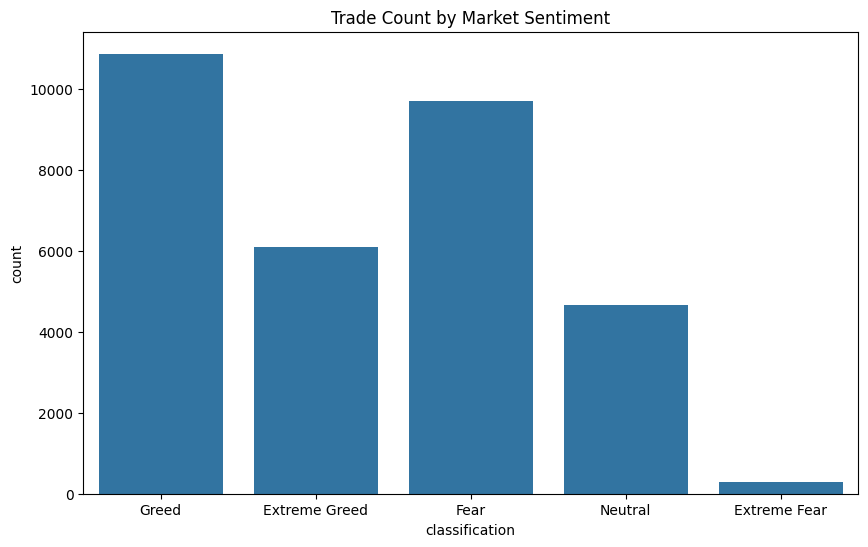

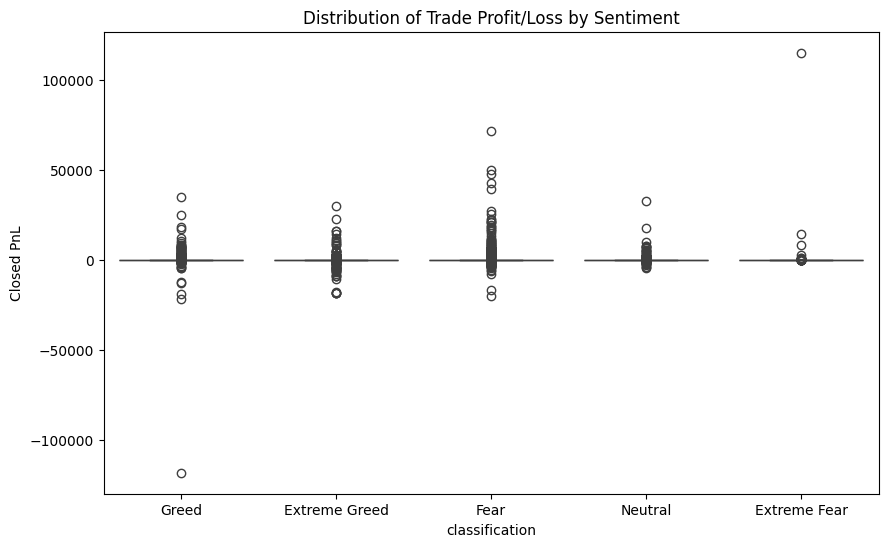

In [11]:
# Plot trade volume by sentiment
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_df, x='classification')
plt.title('Trade Count by Market Sentiment')
plt.show()

# Compare average closedPnL in Fear vs Greed
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='Closed PnL', data=merged_df)
plt.title('Distribution of Trade Profit/Loss by Sentiment')
plt.show()

In [13]:
import os

# Create directories if they don't exist
os.makedirs('csv_files', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Save processed merged dataset to CSV for submission
merged_df.to_csv('csv_files/merged_trader_sentiment.csv', index=False)

# Save generated plots to outputs folder
plt.savefig('outputs/trade_volume_by_sentiment.png')
plt.savefig('outputs/closedPnL_distribution.png')
# plt.savefig('outputs/correlation_heatmap.png') # This plot was not generated

<Figure size 640x480 with 0 Axes>